# Load Data

In [1]:
from google.colab import drive

# Mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


Copy dataset from google drive to local colab environment

Link to dataset: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification

In [2]:
import os

# Define the path to your zipped file in Google Drive
zipped_file_path = '/content/drive/MyDrive/WasteDataset.zip'

# Define the destination directory in your Colab environment
dataset_path = '/content/dataset/'

# Create the destination directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

In [3]:
# Copy the zipped file to the local Colab environment
!cp "{zipped_file_path}" "{dataset_path}"

In [4]:
# Change to the destination directory
%cd "{dataset_path}"

!unzip -qq "{os.path.basename(zipped_file_path)}"

# Go back to the original content directory
%cd /content

/content/dataset
/content


In [5]:
# List the contents of the unzipped directory
!ls -F "{dataset_path}"

images/  README.txt  WasteDataset.zip


### Preprocess and load images
Note: Trying to load all images into memory at once consumes too much RAM, so images are loaded through their paths dynamically using tf dataset

In [6]:
import tensorflow as tf
import os

In [7]:
# Settings
dataset_root = "/content/dataset/images/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.1 # 10% validation
TEST_SPLIT = 0.1 # 10% test
SEED = 42

In [8]:
# Training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT, # 20% reserved for val+test
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical" # one-hot encoded labels
)

# Temp dataset: 20% reserved for val+test
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 15000 files belonging to 30 classes.
Using 12000 files for training.
Found 15000 files belonging to 30 classes.
Using 3000 files for validation.


In [9]:
# Convert to a list of batches for splitting
temp_images = []
temp_labels = []

for images, labels in temp_dataset:
    temp_images.append(images)
    temp_labels.append(labels)

# Concatenate all batches
temp_images = tf.concat(temp_images, axis=0)
temp_labels = tf.concat(temp_labels, axis=0)

# Compute split indices
num_temp = temp_images.shape[0]
num_val = int(num_temp * (VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)))

X_val = temp_images[:num_val]
y_val = temp_labels[:num_val]

X_test = temp_images[num_val:]
y_test = temp_labels[num_val:]

# Convert back to tf.data.Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
class_names = train_dataset.class_names
idx_to_class = {i: name for i, name in enumerate(class_names)}

print("Num Classes: ", len(class_names))
print("Classes:", class_names)
print("Number of training batches:", tf.data.experimental.cardinality(train_dataset).numpy())

Num Classes:  30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']
Number of training batches: 375


In [11]:
def count_images(dataset):
    count = 0
    for images, _ in dataset:
        count += images.shape[0]
    return count

In [12]:
# Final full datasets to use
print("Train Dataset: ", train_dataset)
print("Train images count:", count_images(train_dataset))

print("Val Dataset: ", val_dataset)
print("Val images count:", count_images(val_dataset))

print("Test Dataset: ", test_dataset)
print("Test images count:", count_images(test_dataset))

Train Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Train images count: 12000
Val Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Val images count: 1500
Test Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Test images count: 1500


## Visualize the data

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, class_names=None):
    plt.figure(figsize=(8, 8))

    # Take one batch only
    for images, labels in dataset.take(1):
        for i in range(8):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            if class_names is not None:
                label_idx = np.argmax(labels[i])
                plt.title(class_names[label_idx])

            plt.axis("off")

    plt.tight_layout()
    plt.show()

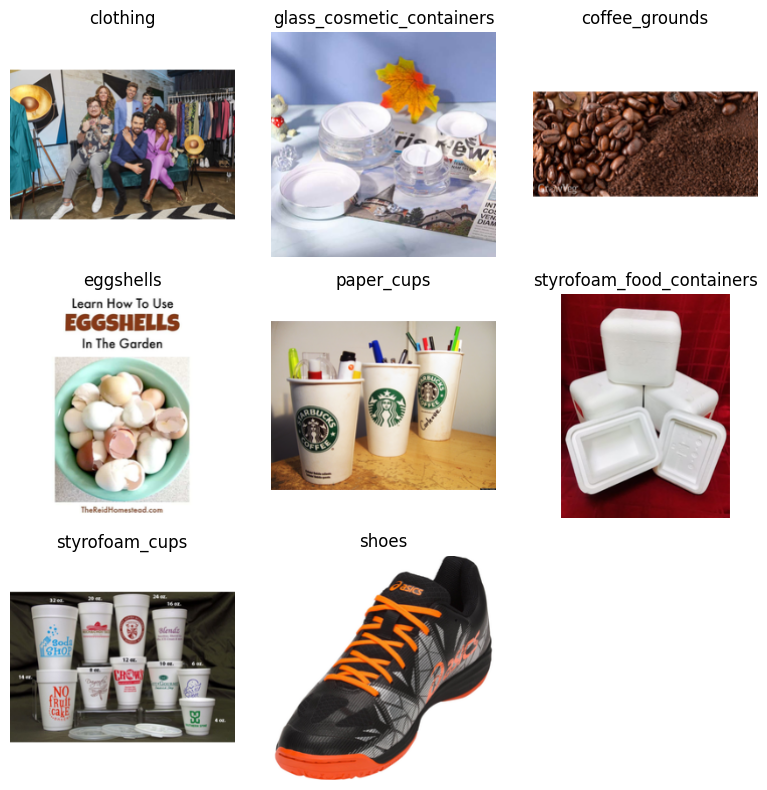

In [14]:
show_images(train_dataset, class_names)

# Training

## Setup functions for training and eval

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    ConfusionMatrixDisplay
)

def plot_loss_acc_training(history):
    """
    Plots training vs. validation accuracy and loss over epochs.

    Args:
        history: Keras History object returned by model.fit()
    """
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()


def plot_predictions_grid(model, dataset, class_names, num_images=9):
    """
    Displays a grid of images with the model's predicted label and confidence.
    Titles are green for correct predictions and red for incorrect ones.

    Args:
        model:       Trained Keras/TF model
        dataset:     Batched tf.data.Dataset of (image, label) pairs
        class_names: List of class label strings
        num_images:  Number of images to display (default: 9)
    """
    cols = 3
    rows = (num_images + cols - 1) // cols

    images, true_labels = next(iter(
        dataset.unbatch().shuffle(buffer_size=1000).batch(num_images)
    ))

    images = images.numpy()
    true_labels = true_labels.numpy()

    plt.figure(figsize=(cols * 3, rows * 3))

    for i in range(num_images):
        img_array = np.expand_dims(images[i], axis=0)
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100

        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].astype("uint8") if images[i].max() > 1 else images[i], cmap="gray")
        plt.axis("off")

        title = f"{class_names[predicted_index]} ({confidence:.1f}%)"
        true_label_i = int(np.argmax(true_labels[i]))
        color = "green" if predicted_index == true_label_i else "red"
        plt.title(title + f"\n[{class_names[true_label_i]}]", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()


def evaluate_metrics(model, test_dataset, y_test):
    """
    Prints and returns Loss, Accuracy, Precision, Recall, and F1-Score.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched dataset used for predictions
        y_test:       One-hot encoded true labels (tensor)
    """
    predicted   = model.predict(test_dataset)
    predicted_i = np.argmax(predicted, axis=1)
    actual      = np.argmax(y_test.numpy(), axis=1)

    test_loss, _ = model.evaluate(test_dataset)

    accuracy  = accuracy_score(actual, predicted_i)
    precision = precision_score(actual, predicted_i, average="weighted")
    recall    = recall_score(actual, predicted_i, average="weighted")
    f1        = f1_score(actual, predicted_i, average="weighted")

    print(f"Loss:      {test_loss:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return {"loss": test_loss, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(model, test_dataset, y_test, class_names):
    """
    Displays a confusion matrix for the model's predictions.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched dataset used for predictions
        y_test:       One-hot encoded true labels (tensor)
        class_names:  List of class label strings
    """
    predicted   = model.predict(test_dataset)
    predicted_i = np.argmax(predicted, axis=1)
    actual      = np.argmax(y_test.numpy(), axis=1)

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay.from_predictions(
        actual,
        predicted_i,
        ax=ax,
        display_labels=class_names
    )
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix")
    plt.show()

def save_model_to_drive(model, filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and saves a trained Keras model to it.

    Args:
        model:      Trained Keras/TF model
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")
    """
    drive.mount("/content/drive", force_remount=False)

    save_dir = f"/content/drive/{drive_path}"
    os.makedirs(save_dir, exist_ok=True)

    full_path = f"{save_dir}/{filename}"
    model.save(full_path)
    print(f"Model saved to: {full_path}")

def load_model_from_drive(filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and loads a Keras model from it.

    Args:
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")

    Returns:
        Loaded Keras model
    """
    drive.mount("/content/drive", force_remount=False)

    full_path = f"/content/drive/{drive_path}/{filename}"

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No model found at: {full_path}")

    model = keras.models.load_model(full_path)
    print(f"Model loaded from: {full_path}")
    return model

## Create the small model

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │       768,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,526 (6.66 MB)

 Trainable params: 1,746,526 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

In [18]:
# Choose loss function, optimizer, and metrics
model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

# Callback function to save best model during training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
]

In [19]:
# Train the model without augmentation
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.0891 - loss: 3.2769 - val_accuracy: 0.1860 - val_loss: 2.7817
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2783 - loss: 2.5762 - val_accuracy: 0.3860 - val_loss: 2.1431
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4451 - loss: 1.9803 - val_accuracy: 0.4740 - val_loss: 1.8687
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5850 - loss: 1.4792 - val_accuracy: 0.5293 - val_loss: 1.8019
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7013 - loss: 1.0384 - val_accuracy: 0.5593 - val_loss: 1.7932
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7879 - loss: 0.7184 - val_accuracy: 0.6273 - val_loss: 1.8879
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8518 - loss: 0.4867 - val_accuracy: 0.6267 - val_loss: 2.3769
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8922 - loss: 0.3758 - val_acc

In [20]:
# Retrieve and display the final training and validation accuracy as percentages
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

Final Training Accuracy: 92.73%
Final Validation Accuracy: 64.93%


### Display loss curve

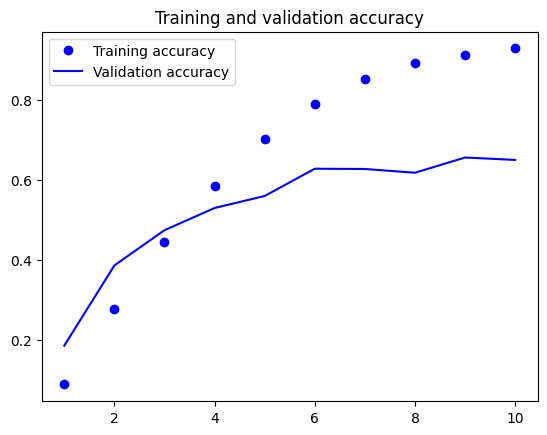

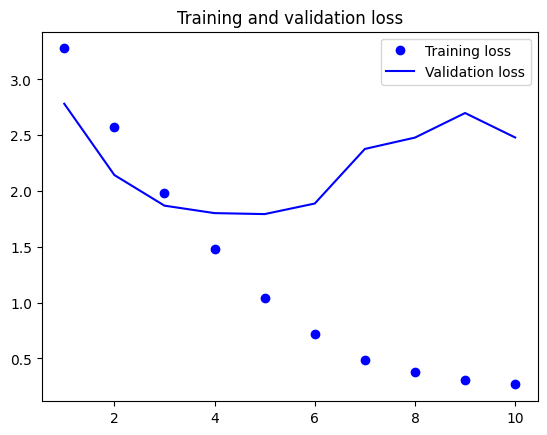

In [21]:
plot_loss_acc_training(history)

### Save the model

In [22]:
save_model_to_drive(model, "model.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/model.keras


### Load the model (if needed)

In [23]:
model = load_model_from_drive("model.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/model.keras


### Evaluate the model

In [24]:
evaluate_metrics(model, test_dataset, y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5747 - loss: 1.7907
Loss:      1.7907
Accuracy:  0.5747
Precision: 0.6067
Recall:    0.5747
F1-Score:  0.5772


{'loss': 1.7907006740570068,
 'accuracy': 0.5746666666666667,
 'precision': 0.6066864744994559,
 'recall': 0.5746666666666667,
 'f1': 0.5772395254663869}

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


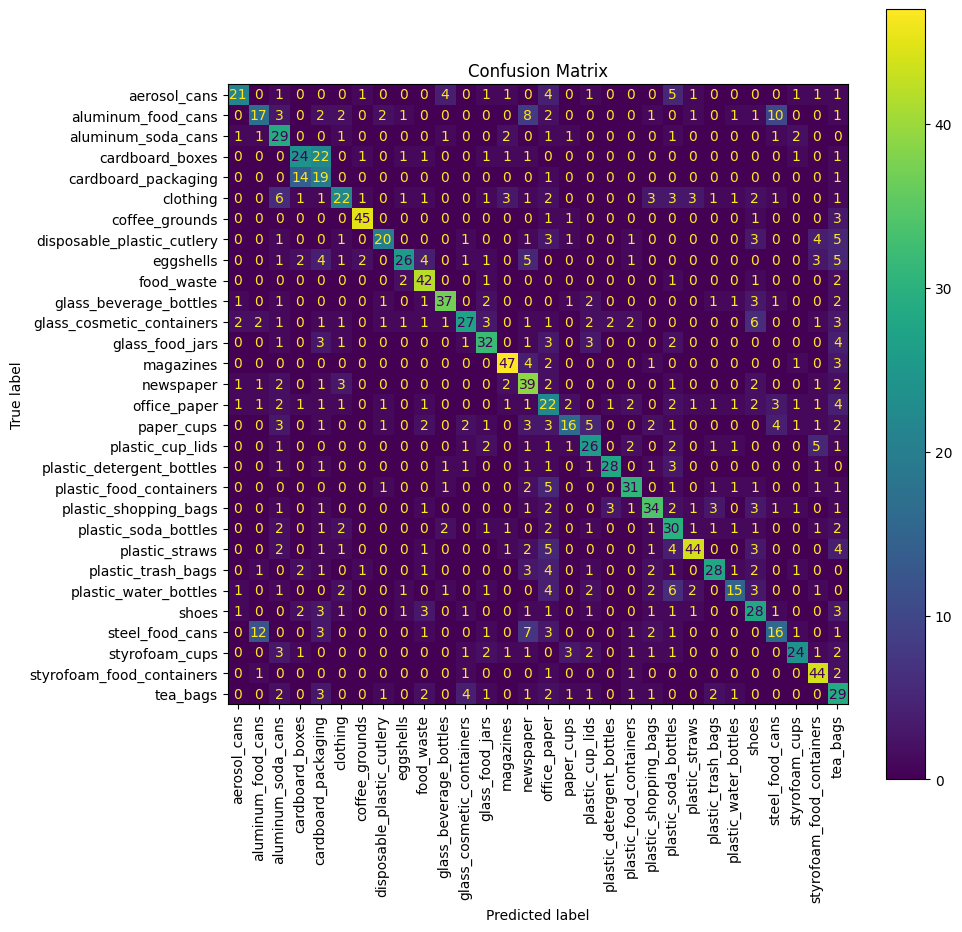

In [25]:
plot_confusion_matrix(model, test_dataset, y_test, class_names)

### Plot images with model predictions vs. actual labels

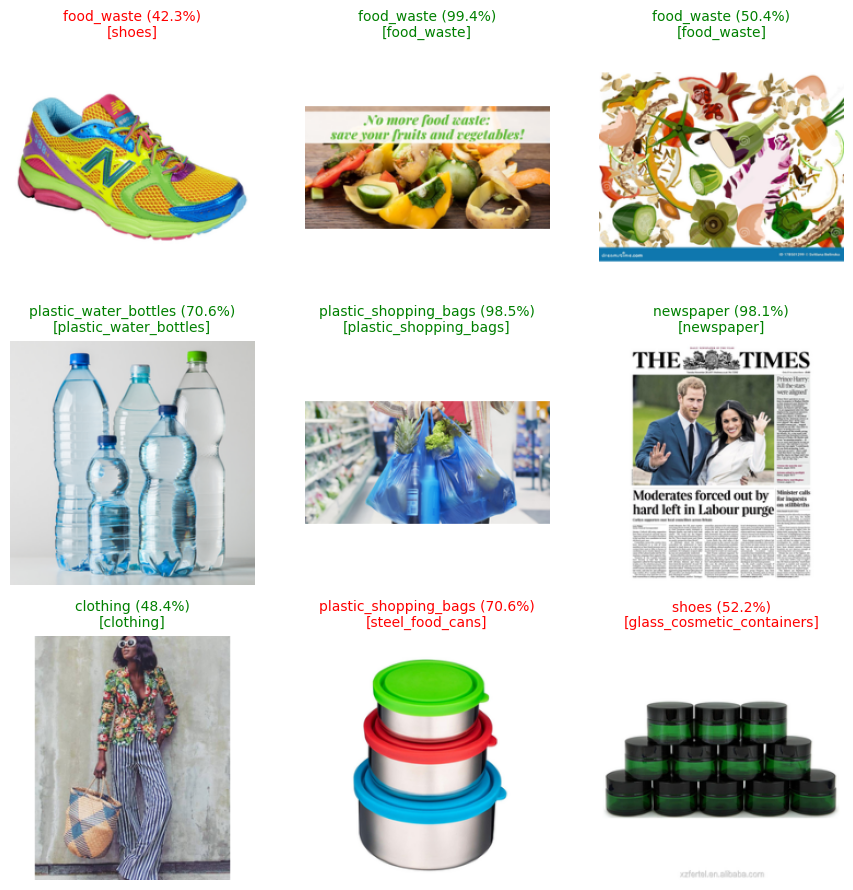

In [26]:
plot_predictions_grid(model, test_dataset, class_names, num_images=9)

## Create Model on ConvNeXtLarge

In [27]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtLarge

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
        layers.RandomBrightness(0.2),
    ]
)

Create ConvNeXtLarge

In [28]:
eff_model = ConvNeXtLarge(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(IMG_SIZE + (3,))
)

785596384/785596384 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step


In [29]:
#Layers
inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = data_augmentation(inputs)
x = eff_model(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [30]:
#View Layers
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 1536)           │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        46,110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,276,446 (748.74 MB)

 Trainable params: 196,276,446 (748.74 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# PHASE 1: Train only the new head
# Freeze the entire base model so its weights don't change
eff_model.trainable = False

# Higher LR is fine here because we're only training the small Dense head
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

phase1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="ConvNeXtLarge_phase1.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
]

In [32]:
# Phase 1: train head only
print("=" * 50)
print("PHASE 1: Training classifier head (base frozen)")
print("=" * 50)
history_p1 = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=phase1_callbacks
)

# Phase 2: unfreeze base, fine-tune everything with tiny LR
print("=" * 50)
print("PHASE 2: Fine-tuning full model (base unfrozen)")
print("=" * 50)

# Unfreeze the base model
eff_model.trainable = True

# CRITICAL: must recompile after changing trainable status
# Use 10x-100x lower LR than Phase 1
optimizer = keras.optimizers.Adam(learning_rate=1e-5)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

phase2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="ConvNeXtLarge_finetuned.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=val_dataset,
    callbacks=phase2_callbacks
)

PHASE 1: Training classifier head (base frozen)
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 166s 360ms/step - accuracy: 0.6926 - loss: 1.0842 - val_accuracy: 0.8627 - val_loss: 0.4033
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 289ms/step - accuracy: 0.8196 - loss: 0.5626 - val_accuracy: 0.8673 - val_loss: 0.4088
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 113s 300ms/step - accuracy: 0.8418 - loss: 0.4874 - val_accuracy: 0.8780 - val_loss: 0.3478
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 290ms/step - accuracy: 0.8513 - loss: 0.4461 - val_accuracy: 0.8833 - val_loss: 0.3600
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 290ms/step - accuracy: 0.8636 - loss: 0.4186 - val_accuracy: 0.8887 - val_loss: 0.3508
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 290ms/step - accuracy: 0.8708 - loss: 0.4009 - val_accuracy: 0.8807 - val_loss: 0.3682
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 290ms/step - accuracy: 0.8683 - loss: 0.3966 - val_accuracy: 0.8887 - val_loss: 0.3525
PHASE 2: Fine-tuning full mo

### Save the model

In [33]:
save_model_to_drive(model, "ConvNeXtLarge.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/ConvNeXtLarge.keras


### Load the model (if needed)

In [34]:
model = load_model_from_drive("ConvNeXtLarge.keras")
print("Loaded best fine-tuned ConvNeXtLarge checkpoint")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/ConvNeXtLarge.keras
Loaded best fine-tuned ConvNeXtLarge checkpoint


### Evaluate the model

In [35]:
evaluate_metrics(model, test_dataset, y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 438ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 383ms/step - accuracy: 0.9080 - loss: 0.2560
Loss:      0.2560
Accuracy:  0.9080
Precision: 0.9093
Recall:    0.9080
F1-Score:  0.9079


{'loss': 0.2560220956802368,
 'accuracy': 0.908,
 'precision': 0.9092774810370785,
 'recall': 0.908,
 'f1': 0.9079343723054161}

Confusion Matrix

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step


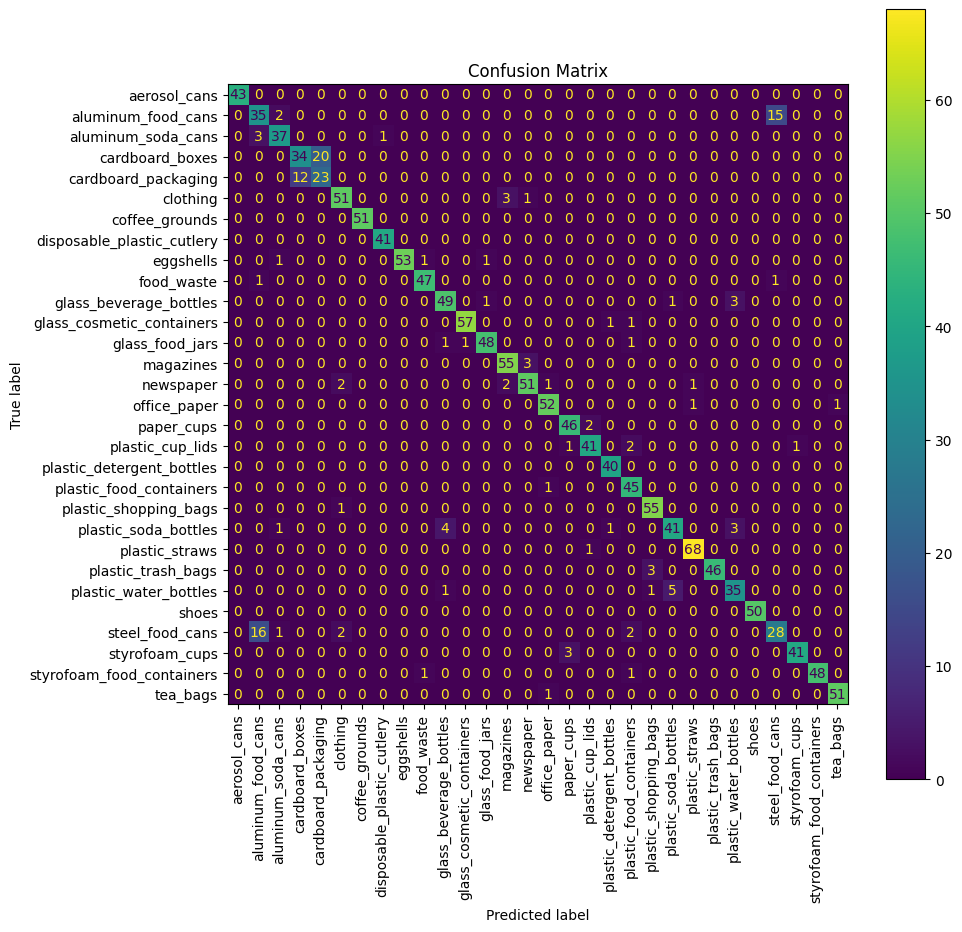

In [36]:
plot_confusion_matrix(model, test_dataset, y_test, class_names)

Plot Loss

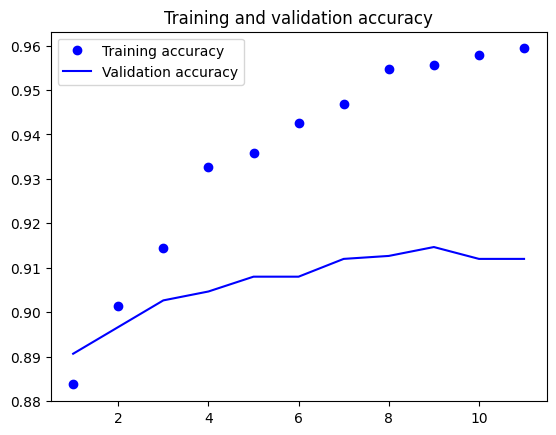

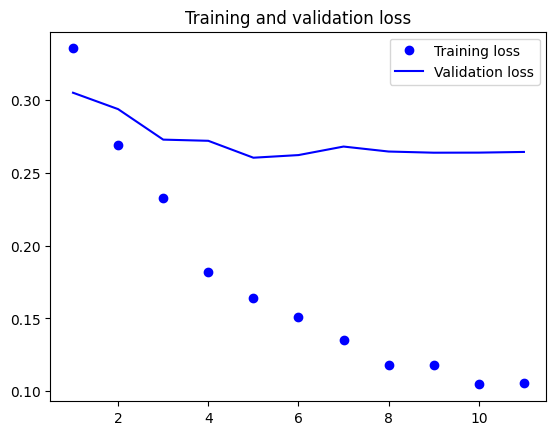

In [37]:
plot_loss_acc_training(history)

### Plot images with model predictions vs. actual labels

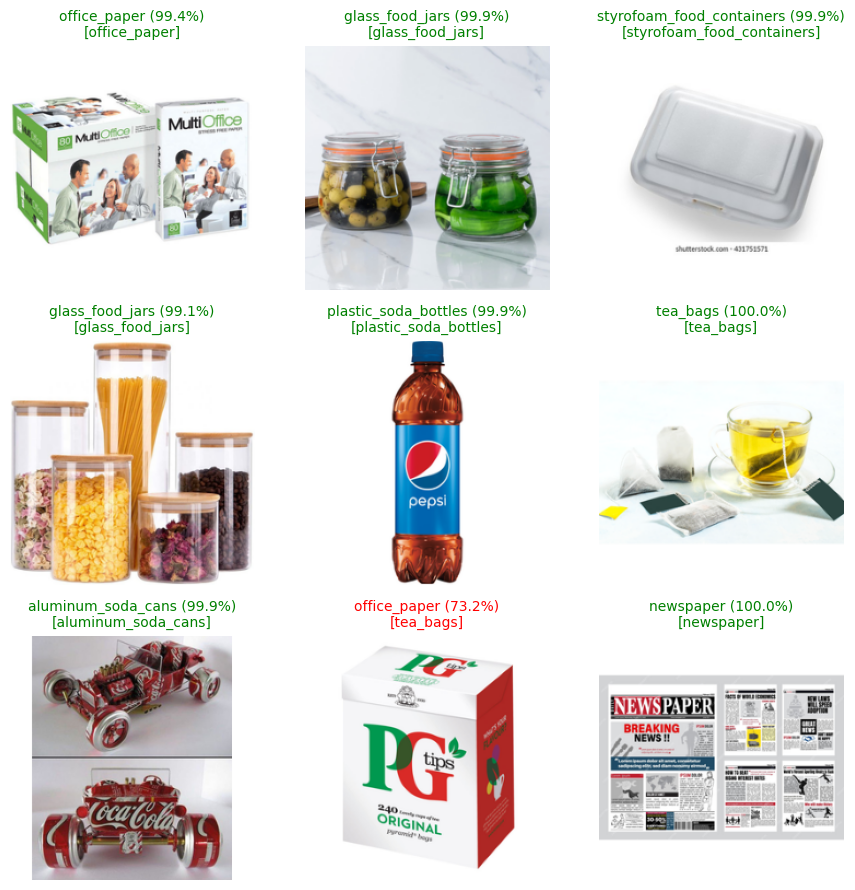

In [38]:
plot_predictions_grid(model, test_dataset, class_names, num_images=9)

In [39]:
import io
import numpy as np
import tensorflow as tf
import ipywidgets as widgets
from PIL import Image
from IPython.display import display, clear_output
from tensorflow.keras.applications.convnext import preprocess_input


IMG_SIZE = (224, 224)

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description="Upload Waste Image"
)

clear_button = widgets.Button(
    description="Clear Results",
    button_style='warning'
)

output = widgets.Output()

progress = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description='Predicting:',
    bar_style='info',
    layout={'visibility': 'hidden', 'width': '500px'}
)


def preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    display_img = img.copy()

    img = img.resize(IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)

    # EfficientNetV2 preprocessing
    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)
    return display_img, img_array


def on_upload_change(change):
    with output:
        clear_output()

        if not uploader.value:
            return

        progress.layout.visibility = 'visible'
        progress.value = 15

        uploaded_file = list(uploader.value.values())[0]
        image_bytes = uploaded_file["content"]

        display_img, input_tensor = preprocess_image(image_bytes)
        progress.value = 50

        preds = model.predict(input_tensor, verbose=0)[0]
        progress.value = 85

        top_3_indices = np.argsort(preds)[-3:][::-1]

        # Show uploaded image
        display(widgets.HTML("<h2>Waste Classification Tester</h2>"))
        display(widgets.HTML("<h4>Uploaded Image</h4>"))
        display(display_img.resize((250, 250)))

        # Best prediction
        best_idx = top_3_indices[0]
        best_label = class_names[best_idx]
        best_conf = preds[best_idx] * 100

        display(widgets.HTML(
            f"<h3>Best Prediction: <span style='color:green'>{best_label}</span></h3>"
        ))
        display(widgets.HTML(
            f"<h4>Confidence: {best_conf:.2f}%</h4>"
        ))

        # Optional low-confidence warning
        if best_conf < 60:
            display(widgets.HTML(
                "<p style='color:red;'><b>Warning:</b> Model confidence is low. This prediction may be uncertain.</p>"
            ))

        # Top 3 predictions
        display(widgets.HTML("<h3>Top 3 Predictions</h3>"))

        bar_styles = ['success', 'info', 'warning']
        top3_widgets = []

        for rank, i in enumerate(top_3_indices):
            label = class_names[i]
            prob = preds[i] * 100

            label_html = widgets.HTML(
                f"<b>{rank+1}. {label}</b> — {prob:.2f}%"
            )

            bar = widgets.FloatProgress(
                value=prob,
                min=0,
                max=100,
                description='',
                bar_style=bar_styles[rank] if rank < len(bar_styles) else '',
                layout={'width': '450px'}
            )

            top3_widgets.append(widgets.VBox([label_html, bar]))

        display(widgets.VBox(top3_widgets))

        progress.value = 100
        progress.layout.visibility = 'hidden'
        progress.value = 0

def on_clear_clicked(b):
    with output:
        clear_output()
        display(widgets.HTML("<h3>Results cleared. Upload another image.</h3>"))

    progress.layout.visibility = 'hidden'
    progress.value = 0

uploader.observe(on_upload_change, names='value')
clear_button.on_click(on_clear_clicked)

header = widgets.HTML("<h1>♻️ Smart Recycling Classifier</h1>")
subtext = widgets.HTML("<p>Upload an image to test your fine-tuned EfficientNetV2 model.</p>")
controls = widgets.HBox([uploader, clear_button])

display(header, subtext, controls, progress, output)

HTML(value='<h1>♻️ Smart Recycling Classifier</h1>')

HTML(value='<p>Upload an image to test your fine-tuned EfficientNetV2 model.</p>')

IntProgress(value=0, bar_style='info', description='Predicting:', layout=Layout(visibility='hidden', width='50…

Output()